# 정밀 Mutation Feature 실험 수정판 001

기존 `precision_mutation_features.ipynb`의 benchmark 형식을 유지하면서, 외부 데이터 없이 수기 도메인 후보를 검증합니다.

## 실험 순서

1. **DOMAIN-01**: 암종 관련 gene group 요약
2. **DOMAIN-02**: 알려진 gene-mutation 조합
3. **DOMAIN-03**: 제한된 gene pair 조합
4. **DOMAIN-04A/B**: 도메인 선택 20개와 fold-train 통계 선택 20개 비교
5. 도메인 피처 조합

기존 baseline, StratifiedKFold, Logistic Regression/LightGBM, Macro F1 및 baseline 대비 delta 계산을 그대로 사용합니다. 각 fold의 train 데이터로만 자동 선택 피처를 생성하여 누수를 방지합니다.

In [1]:
from __future__ import annotations

from collections import Counter
from dataclasses import dataclass
import os
from pathlib import Path
import re
import sys
import tempfile
from typing import Any

os.environ.setdefault('MPLCONFIGDIR', str(Path(tempfile.gettempdir()) / 'matplotlib-member-b-domain'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import sparse
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.feature_selection import chi2
from sklearn.pipeline import Pipeline
from tqdm.auto import tqdm


def find_project_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / 'requirements.txt').exists() and (path / 'experiments').exists():
            return path
    raise FileNotFoundError('저장소 루트를 찾지 못했습니다.')


ROOT = find_project_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from common.preprocessing_benchmark import run_preprocessing_benchmark
from common.starter_preprocess import make_baseline_preprocessor

print('project root:', ROOT)

project root: /Users/admin/Documents/FinalProject/OZ_fianl_hackaton


/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
@dataclass(frozen=True)
class NotebookConfig:
    id_col: str = 'ID'
    target_col: str = 'SUBCLASS'
    wt_value: str = 'WT'
    auto_feature_count: int = 20


CONFIG = NotebookConfig()
EXPERIMENT_MODE = 'benchmark'  # 'benchmark' | 'fast'
FAST_SAMPLE_PER_CLASS = 30
RUN_MODELS = ['logistic', 'lightgbm']
USE_CONFIRMATION = False

train_df = pd.read_csv(ROOT / 'data' / 'raw' / 'train.csv')


def prepare_experiment_dataset(dataframe: pd.DataFrame) -> pd.DataFrame:
    if EXPERIMENT_MODE == 'benchmark':
        return dataframe.copy()
    parts = []
    for _, class_frame in dataframe.groupby(CONFIG.target_col, sort=True):
        n = min(len(class_frame), max(FAST_SAMPLE_PER_CLASS, 5))
        parts.append(class_frame.sample(n=n, random_state=42))
    return pd.concat(parts, ignore_index=True)


experiment_train_df = prepare_experiment_dataset(train_df)
GENE_COLUMNS = [c for c in train_df.columns if c not in {CONFIG.id_col, CONFIG.target_col}]
print('train shape:', train_df.shape)
print('experiment rows:', len(experiment_train_df))
print('gene columns:', len(GENE_COLUMNS))

train shape: (6201, 4386)
experiment rows: 6201
gene columns: 4384


## 수기 도메인 목록

아래 목록은 이 노트북에서 사용하는 유일한 도메인 입력입니다. 별도 데이터베이스, 논문 파일, 외부 gene list를 자동 다운로드하거나 참조하지 않습니다.

In [3]:
DOMAIN_GENE_GROUPS = {
    'COAD_READ': ['APC', 'KRAS', 'TP53'],
    'BRCA': ['PIK3CA', 'TP53', 'CDH1'],
    'LGG_GBMLGG': ['IDH1', 'TP53', 'ATRX'],
    'KIRC_KIPAN': ['VHL'],
    'LAML': ['NPM1', 'IDH1', 'IDH2', 'RUNX1'],
}

DOMAIN_EXACT_EVENTS = [
    ('BRAF', 'V600E'),
    ('IDH1', 'R132H'),
    ('PIK3CA', 'H1047R'),
    ('PIK3CA', 'E545K'),
]

DOMAIN_GENE_PAIRS = [
    ('IDH1', 'TP53'),
    ('IDH1', 'ATRX'),
    ('APC', 'TP53'),
    ('PIK3CA', 'TP53'),
]

# DOMAIN-04A: 같은 20개를 고정해 DOMAIN-04B와 비교합니다.
DOMAIN_04_FEATURES = (
    [f'group_count_{name}' for name in DOMAIN_GENE_GROUPS]
    + [f'exact_{gene}_{token}' for gene, token in DOMAIN_EXACT_EVENTS]
    + [f'pair_{gene_a}_{gene_b}' for gene_a, gene_b in DOMAIN_GENE_PAIRS]
    + [f'gene_{gene}' for gene in ['APC', 'KRAS', 'TP53', 'PIK3CA', 'CDH1', 'IDH1', 'VHL']]
)
assert len(DOMAIN_04_FEATURES) == 20

TOKEN_RE = re.compile(r'^(?P<ref>[A-Z])(?P<position>\d+)(?P<alt>[A-Z*])$')


def clean_tokens(value: Any, wt_value: str = 'WT') -> list[str]:
    if pd.isna(value):
        return []
    text = str(value).strip()
    if not text or text == wt_value:
        return []
    return [token for token in text.split() if token and token != wt_value]


def event_counter(dataframe: pd.DataFrame, genes: list[str], wt_value: str) -> Counter:
    counts = Counter()
    for gene in genes:
        if gene not in dataframe.columns:
            continue
        for value in dataframe[gene].array:
            counts.update(f'{gene}::{token}' for token in clean_tokens(value, wt_value))
    return counts

In [4]:
class DomainKnowledgeEncoder(BaseEstimator, TransformerMixin):
    """Baseline binary plus fixed domain features or fold-train selected events."""

    def __init__(self, *, strategy: str = 'domain_all', wt_value: str = 'WT', auto_feature_count: int = 20) -> None:
        self.strategy = strategy
        self.wt_value = wt_value
        self.auto_feature_count = auto_feature_count

    def fit(self, X: pd.DataFrame, y: Any = None):
        if not isinstance(X, pd.DataFrame):
            raise TypeError('DomainKnowledgeEncoder는 pandas DataFrame이 필요합니다.')
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        self.gene_columns_ = list(X.columns)
        normalized = X.reindex(columns=self.gene_columns_).fillna(self.wt_value).astype(str).reset_index(drop=True)
        self.mutated_ = normalized.ne(self.wt_value)
        self.base_feature_names_ = [str(gene) for gene in self.gene_columns_]
        self.selected_auto_events_ = []

        if self.strategy in {'domain_04_auto', 'domain_all'}:
            y_series = pd.Series(y).reset_index(drop=True)
            counts = event_counter(normalized, self.gene_columns_, self.wt_value)
            candidate_keys = [key for key, count in counts.most_common(2000) if count >= 2]
            if candidate_keys:
                event_matrix = np.column_stack([
                    normalized[key.split('::', 1)[0]].map(lambda value, token=key.split('::', 1)[1]: token in clean_tokens(value, self.wt_value)).to_numpy(dtype=np.float32)
                    for key in candidate_keys
                ])
                scores, _ = chi2(event_matrix, y_series)
                order = np.argsort(np.nan_to_num(scores, nan=-np.inf))[::-1]
                self.selected_auto_events_ = [candidate_keys[i] for i in order[:self.auto_feature_count]]

        names = []
        if self.strategy in {'domain_01', 'domain_all'}:
            names.extend(f'group_count_{name}' for name in DOMAIN_GENE_GROUPS)
        if self.strategy in {'domain_02', 'domain_all'}:
            names.extend(f'exact_{gene}_{token}' for gene, token in DOMAIN_EXACT_EVENTS)
        if self.strategy in {'domain_03', 'domain_all'}:
            names.extend(f'pair_{gene_a}_{gene_b}' for gene_a, gene_b in DOMAIN_GENE_PAIRS)
        if self.strategy in {'domain_04_domain'}:
            names.extend(DOMAIN_04_FEATURES)
        if self.strategy in {'domain_04_auto', 'domain_all'}:
            names.extend(f'auto_{key.replace("::", "_")}' for key in self.selected_auto_events_)
        self.extra_feature_names_ = names
        return self

    def _event_column(self, normalized: pd.DataFrame, gene: str, token: str) -> np.ndarray:
        if gene not in normalized.columns:
            return np.zeros(len(normalized), dtype=np.float32)
        return normalized[gene].map(lambda value: token in clean_tokens(value, self.wt_value)).to_numpy(dtype=np.float32)

    def transform(self, X: pd.DataFrame):
        if not hasattr(self, 'feature_names_in_'):
            raise RuntimeError('transform 전에 fit을 실행해야 합니다.')
        normalized = X.reindex(columns=self.gene_columns_).fillna(self.wt_value).astype(str).reset_index(drop=True)
        base = normalized.ne(self.wt_value).to_numpy(dtype=np.float32)
        extra = []

        if self.strategy in {'domain_01', 'domain_all'}:
            for genes in DOMAIN_GENE_GROUPS.values():
                valid = [gene for gene in genes if gene in normalized.columns]
                extra.append(normalized[valid].ne(self.wt_value).sum(axis=1).to_numpy(dtype=np.float32) if valid else np.zeros(len(normalized), dtype=np.float32))
        if self.strategy in {'domain_02', 'domain_all'}:
            extra.extend(self._event_column(normalized, gene, token) for gene, token in DOMAIN_EXACT_EVENTS)
        if self.strategy in {'domain_03', 'domain_all'}:
            for gene_a, gene_b in DOMAIN_GENE_PAIRS:
                a = normalized[gene_a].ne(self.wt_value).to_numpy(dtype=np.float32) if gene_a in normalized else np.zeros(len(normalized))
                b = normalized[gene_b].ne(self.wt_value).to_numpy(dtype=np.float32) if gene_b in normalized else np.zeros(len(normalized))
                extra.append((a * b).astype(np.float32))
        if self.strategy == 'domain_04_domain':
            for name in DOMAIN_04_FEATURES:
                if name.startswith('group_count_'):
                    group = DOMAIN_GENE_GROUPS[name.removeprefix('group_count_')]
                    valid = [gene for gene in group if gene in normalized.columns]
                    extra.append(normalized[valid].ne(self.wt_value).sum(axis=1).to_numpy(dtype=np.float32))
                elif name.startswith('exact_'):
                    _, gene, token = name.split('_', 2)
                    extra.append(self._event_column(normalized, gene, token))
                elif name.startswith('pair_'):
                    _, gene_a, gene_b = name.split('_', 2)
                    a = normalized[gene_a].ne(self.wt_value).to_numpy(dtype=np.float32) if gene_a in normalized else np.zeros(len(normalized), dtype=np.float32)
                    b = normalized[gene_b].ne(self.wt_value).to_numpy(dtype=np.float32) if gene_b in normalized else np.zeros(len(normalized), dtype=np.float32)
                    extra.append((a * b).astype(np.float32))
                else:
                    gene = name.removeprefix('gene_')
                    extra.append(normalized[gene].ne(self.wt_value).to_numpy(dtype=np.float32) if gene in normalized else np.zeros(len(normalized), dtype=np.float32))
        if self.strategy in {'domain_04_auto', 'domain_all'}:
            extra.extend(self._event_column(normalized, *key.split('::', 1)) for key in self.selected_auto_events_)

        if extra:
            return sparse.hstack([sparse.csr_matrix(base), sparse.csr_matrix(np.column_stack(extra), dtype=np.float32)], format='csr')
        return sparse.csr_matrix(base)

    def get_feature_names_out(self, input_features: Any = None) -> np.ndarray:
        del input_features
        return np.asarray(self.base_feature_names_ + self.extra_feature_names_, dtype=object)

In [5]:
EXPERIMENTS = [
    ('team_baseline_binary', '공용 baseline: WT 0/1 binary', make_baseline_preprocessor()),
    ('domain_01_gene_groups', 'DOMAIN-01 암종 관련 gene group count', Pipeline([('domain', DomainKnowledgeEncoder(strategy='domain_01'))])),
    ('domain_02_exact_events', 'DOMAIN-02 수기 gene-mutation 조합 4개', Pipeline([('domain', DomainKnowledgeEncoder(strategy='domain_02'))])),
    ('domain_03_gene_pairs', 'DOMAIN-03 제한된 gene pair 4개', Pipeline([('domain', DomainKnowledgeEncoder(strategy='domain_03'))])),
    ('domain_04A_domain_20', 'DOMAIN-04A 도메인 선택 20개', Pipeline([('domain', DomainKnowledgeEncoder(strategy='domain_04_domain'))])),
    ('domain_04B_auto_20', 'DOMAIN-04B fold-train 통계 선택 20개', Pipeline([('domain', DomainKnowledgeEncoder(strategy='domain_04_auto'))])),
    ('domain_all_01_02_03_auto', 'DOMAIN-01 + 02 + 03 + 자동 20개', Pipeline([('domain', DomainKnowledgeEncoder(strategy='domain_all'))])),
]
print('experiment count:', len(EXPERIMENTS))

experiment count: 7


In [6]:
summary_rows = []
fold_metric_frames = []

total_runs = len(EXPERIMENTS) * len(RUN_MODELS)
with tqdm(total=total_runs, desc='Precision feature experiments') as progress:
    for experiment_name, description, preprocessor in EXPERIMENTS:
        for model_name in RUN_MODELS:
            result = run_preprocessing_benchmark(
                experiment_train_df,
                clone(preprocessor),
                experiment_id=experiment_name,
                preprocessing_name=description,
                model=model_name,
                confirmation=USE_CONFIRMATION,
                target_column=CONFIG.target_col,
                id_column=CONFIG.id_col,
                verbose=False,
            )
            summary_rows.append({
                'experiment': experiment_name,
                'description': description,
                'model': model_name,
                'oof_macro_f1': result.summary['oof_f1_macro_mean'],
                'oof_accuracy': result.summary['oof_accuracy_mean'],
                'fold_macro_f1_mean': result.summary['fold_f1_macro_mean'],
                'fold_macro_f1_std': result.summary['fold_f1_macro_std'],
                'feature_count_mean': result.fold_metrics['feature_count'].mean(),
                'elapsed_seconds': result.summary['elapsed_seconds'],
            })
            fold_df = result.fold_metrics.copy()
            fold_df['experiment'] = experiment_name
            fold_df['model'] = model_name
            fold_metric_frames.append(fold_df)
            progress.update(1)

results = pd.DataFrame(summary_rows)
baseline_scores = results[results['experiment'] == 'team_baseline_binary'].set_index('model')['oof_macro_f1']
results['baseline_macro_f1'] = results['model'].map(baseline_scores)
results['delta_vs_baseline'] = results['oof_macro_f1'] - results['baseline_macro_f1']
fold_results = pd.concat(fold_metric_frames, ignore_index=True)

display(results.sort_values(['model', 'oof_macro_f1'], ascending=[True, False]))

Precision feature experiments: 100%|██████████| 14/14 [1:22:31<00:00, 353.70s/it]


,experiment,description,model,oof_macro_f1,oof_accuracy,fold_macro_f1_mean,fold_macro_f1_std,feature_count_mean,elapsed_seconds,baseline_macro_f1,delta_vs_baseline
9,domain_04A_domain_20,DOMAIN-04A 도메인 선택 20개,lightgbm,0.294655,0.306080,0.292609,0.014754,4404.0,583.732464,0.290581,0.004074
13,domain_all_01_02_03_auto,DOMAIN-01 + 02 + 03 + 자동 20개,lightgbm,0.293995,0.308176,0.292289,0.004252,4417.0,720.029668,0.290581,0.003414
7,domain_03_gene_pairs,DOMAIN-03 제한된 gene pair 4개,lightgbm,0.291796,0.306402,0.290311,0.014164,4388.0,622.560343,0.290581,0.001215
11,domain_04B_auto_20,DOMAIN-04B fold-train 통계 선택 20개,lightgbm,0.291318,0.305273,0.289852,0.013875,4404.0,733.553833,0.290581,0.000737
1,team_baseline_binary,공용 baseline: WT 0/1 binary,lightgbm,0.290581,0.304628,0.289075,0.010428,4384.0,573.860847,0.290581,0.000000
3,domain_01_gene_groups,DOMAIN-01 암종 관련 gene group count,lightgbm,0.290351,0.306080,0.289002,0.010365,4389.0,595.392584,0.290581,-0.000230
5,domain_02_exact_events,DOMAIN-02 수기 gene-mutation 조합 4개,lightgbm,0.286801,0.303822,0.285349,0.009926,4388.0,623.987752,0.290581,-0.003780
8,domain_04A_domain_20,DOMAIN-04A 도메인 선택 20개,logistic,0.348222,0.344944,0.346567,0.006890,4404.0,42.998425,0.344689,0.003533
12,domain_all_01_02_03_auto,DOMAIN-01 + 02 + 03 + 자동 20개,logistic,0.347767,0.345589,0.345782,0.009050,4417.0,146.564946,0.344689,0.003079
4,domain_02_exact_events,DOMAIN-02 수기 gene-mutation 조합 4개,logistic,0.347278,0.346557,0.345921,0.008819,4388.0,42.304605,0.344689,0.002589


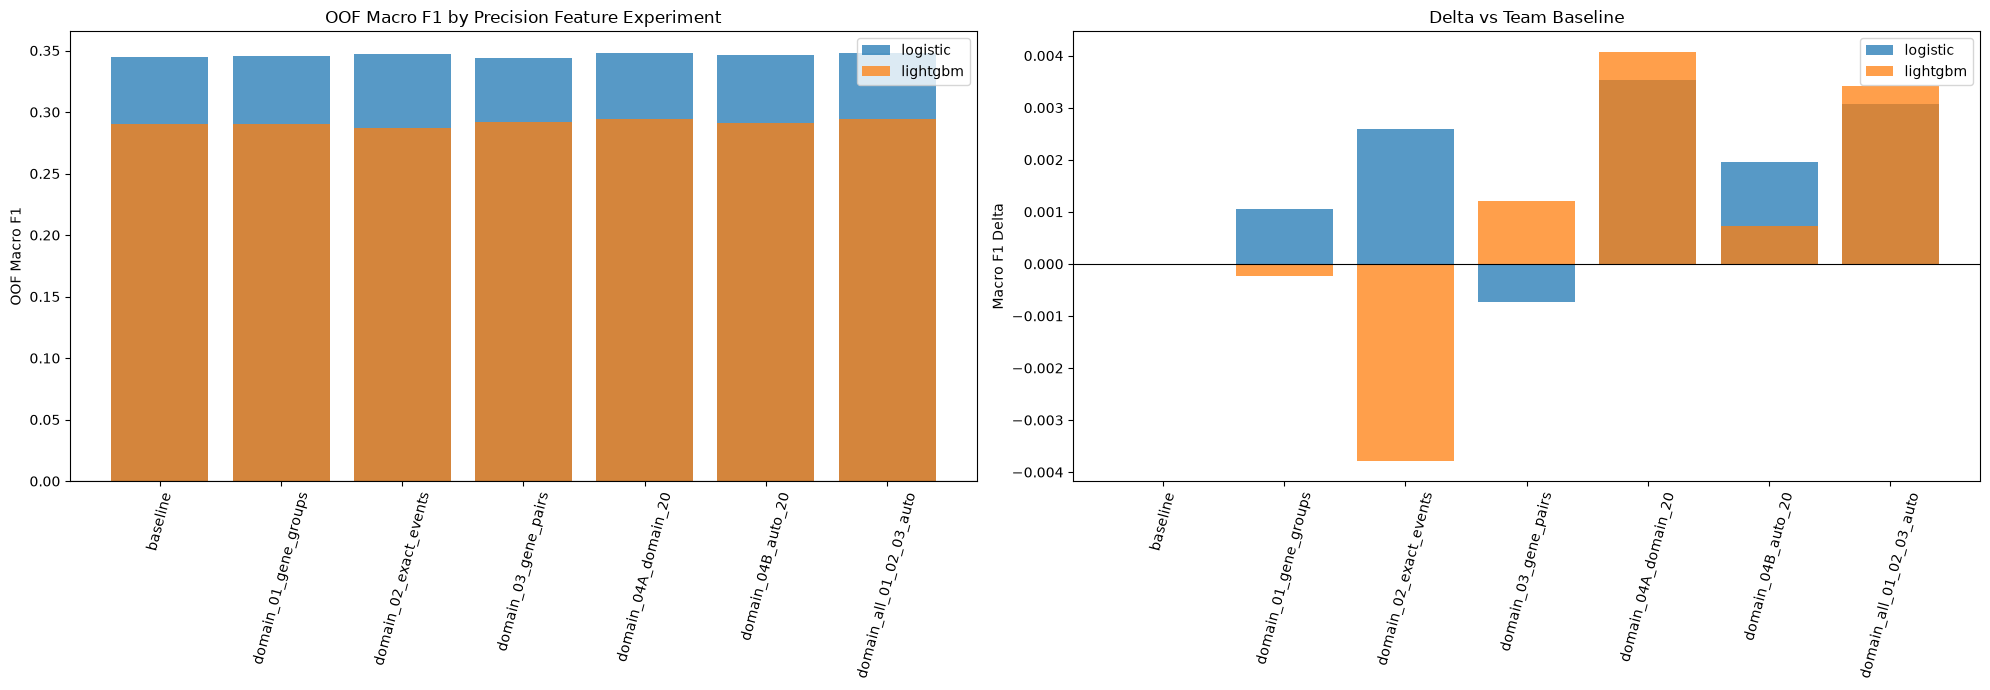

,experiment,model,oof_macro_f1,fold_macro_f1_std,feature_count_mean,delta_vs_baseline
9,domain_04A_domain_20,lightgbm,0.294655,0.014754,4404.0,0.004074
13,domain_all_01_02_03_auto,lightgbm,0.293995,0.004252,4417.0,0.003414
7,domain_03_gene_pairs,lightgbm,0.291796,0.014164,4388.0,0.001215
11,domain_04B_auto_20,lightgbm,0.291318,0.013875,4404.0,0.000737
1,team_baseline_binary,lightgbm,0.290581,0.010428,4384.0,0.000000
3,domain_01_gene_groups,lightgbm,0.290351,0.010365,4389.0,-0.000230
5,domain_02_exact_events,lightgbm,0.286801,0.009926,4388.0,-0.003780
8,domain_04A_domain_20,logistic,0.348222,0.006890,4404.0,0.003533
12,domain_all_01_02_03_auto,logistic,0.347767,0.009050,4417.0,0.003079
4,domain_02_exact_events,logistic,0.347278,0.008819,4388.0,0.002589


In [7]:
plot_data = results.copy()
plot_data['short_experiment'] = plot_data['experiment'].str.replace('baseline_plus_', '', regex=False)
plot_data.loc[plot_data['experiment'] == 'team_baseline_binary', 'short_experiment'] = 'baseline'

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
for model_name, group in plot_data.groupby('model', sort=False):
    axes[0].bar(group['short_experiment'], group['oof_macro_f1'], alpha=0.75, label=model_name)
    axes[1].bar(group['short_experiment'], group['delta_vs_baseline'], alpha=0.75, label=model_name)
axes[0].set_title('OOF Macro F1 by Precision Feature Experiment')
axes[0].set_ylabel('OOF Macro F1')
axes[1].set_title('Delta vs Team Baseline')
axes[1].set_ylabel('Macro F1 Delta')
for ax in axes:
    ax.axhline(0, color='black', linewidth=0.8)
    ax.tick_params(axis='x', rotation=75)
    ax.legend()
plt.tight_layout()
plt.show()

display(results.sort_values(['model', 'delta_vs_baseline'], ascending=[True, False])[['experiment', 'model', 'oof_macro_f1', 'fold_macro_f1_std', 'feature_count_mean', 'delta_vs_baseline']])

## 해석 기준

- `delta_vs_baseline`가 양수인지 먼저 확인합니다.
- DOMAIN-04A와 DOMAIN-04B는 추가 피처 수를 20개로 맞춰 도메인 지식과 fold-train 통계 선택을 비교합니다.
- 도메인 피처가 baseline보다 낮으면 기존 gene binary와 정보가 중복되거나, 후보 목록이 현재 데이터 분포와 맞지 않을 수 있습니다.
- 단일 OOF 상승은 확정 근거로 사용하지 않고, 상승 후보는 `USE_CONFIRMATION = True`로 3-seed 재검증합니다.
- 최종 test 학습 때는 전체 train으로 Transformer를 fit하고 test에는 transform만 적용합니다.